# Incisos del 5 al 8.

### Importación de librerías.

In [36]:
import pickle
from networkx.algorithms import bipartite
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from collections import Counter
import html
import re
import unicodedata

### Importando la red bipartita.

In [2]:
with open("red_bipartita.pkl", "rb") as f:
    G = pickle.load(f)

## Inciso 5.

### 5.1) Proyección autor-autor.

In [3]:
# Nodos autores.
autores = [nodo for nodo, datos in G.nodes(data=True) if datos["tipo"] == "autor"]

# Proyección autor-autor. El peso representa el número de videos compartidos.
G_autores = bipartite.weighted_projected_graph(G, autores)

print("Nodos:", G_autores.number_of_nodes())
print("Aristas:", G_autores.number_of_edges())

Nodos: 332
Aristas: 10732


In [4]:
list(G_autores.edges(data=True))[:2]

[('autor::UCdFlugHJJa4l3YqWuNRmvXw',
  'autor::UC95PSMouTx2N5CbSq0hIyrQ',
  {'weight': 1}),
 ('autor::UCdFlugHJJa4l3YqWuNRmvXw',
  'autor::UCDrmf9y9nLgFY5wnA2hTuGA',
  {'weight': 1})]

### 5.2) Proyección video-video.

In [5]:
# Nodos videos.
videos_grafo = [nodo for nodo, datos in G.nodes(data=True) if datos["tipo"] == "video"]

# Proyección video-video. El peso representa el número de autores compartidos.
G_videos = bipartite.weighted_projected_graph(G, videos_grafo)

print("Nodos:", G_videos.number_of_nodes())
print("Aristas:", G_videos.number_of_edges())

Nodos: 19
Aristas: 11


In [6]:
list(G_videos.edges(data=True))[:2]

[('video::06mFNPU0aB8', 'video::6W4u8sGEnGM', {'weight': 1}),
 ('video::6W4u8sGEnGM', 'video::PjmxCj-a9Hg', {'weight': 1})]

### Comparando las dos proyecciones.

In [7]:
comparacion = pd.DataFrame({
    "red": ["Autor-Autor", "Video-Video"],
    "nodos": [G_autores.number_of_nodes(), G_videos.number_of_nodes()],
    "aristas": [G_autores.number_of_edges(), G_videos.number_of_edges()],
    "densidad": [nx.density(G_autores), nx.density(G_videos)]
})

comparacion

,red,nodos,aristas,densidad
0,Autor-Autor,332,10732,0.195319
1,Video-Video,19,11,0.064327


Autor–autor: Representa si dos autores están relacionados por comentar el mismo contenido; no significa amistad ni interacción directa.

Video–video: Representa si dos videos se relacionan cuando al menos un mismo autor comentó en ambos.

Una mayor densidad en la red autor–autor indicaría mayor coincidencia entre videos en los que comentan autores. Una mayor densidad video–video indicaría similitudes de audiencias entre videos.

### 5.4) Visualizando las proyecciones.

#### Proyección autor-autor.

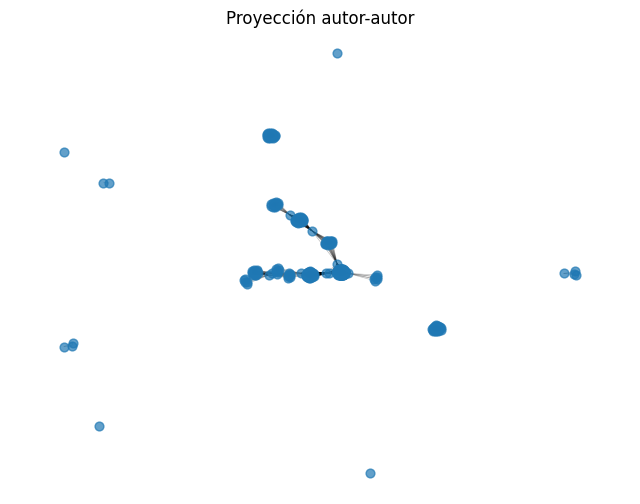

In [8]:
pos_autores = nx.spring_layout(G_autores, seed=42, weight="weight")
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_autores, pos_autores, node_size=40, alpha=0.7)
nx.draw_networkx_edges(G_autores, pos_autores, width=0.5, alpha=0.25)
plt.title("Proyección autor-autor")
plt.axis("off")
plt.show()

Podemos observar que hay una gra cantidad de autores que es posible que sean comentadore de un tipo de contenido de masas, lo cual representa la alta acumulación de en medio, mientras que hay otros que comentan en videos un poco más de nicho.

#### Proyección video-video.

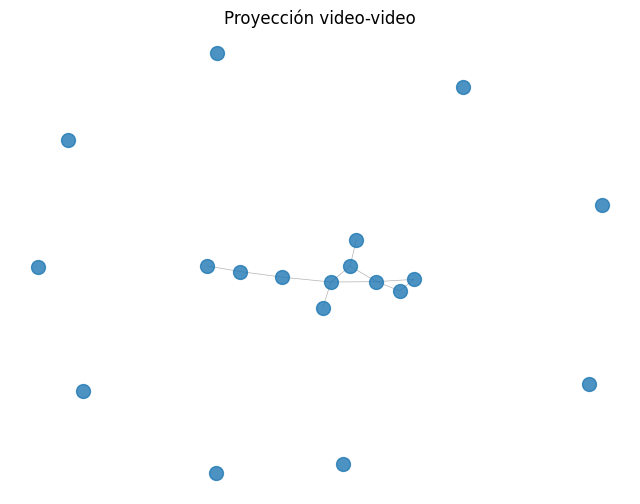

In [9]:
pos_videos = nx.spring_layout(G_videos, seed=42, weight="weight")
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_videos, pos_videos, node_size=100, alpha=0.8)
nx.draw_networkx_edges(G_videos, pos_videos, width=0.5, alpha=0.3)
plt.title("Proyección video-video")
plt.axis("off")
plt.show()

Lod videos del centro pueden estar relacionados por el tipo de contenido.

## Inciso 6.

### 6.1) Topología y fragmentación.

#### Métricas de la red.

In [10]:
def metricas_red(G, nombre):
    grados = dict(G.degree())
    componentes = list(nx.connected_components(G))
    componente_mayor = max(componentes, key=len)
    return {
        "red": nombre,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "densidad": nx.density(G),
        "grado_medio": sum(grados.values()) / G.number_of_nodes(),
        "componentes": len(componentes),
        "componente_mayor": len(componente_mayor)
    }

metricas = pd.DataFrame([
    metricas_red(G, "Bipartita"),
    metricas_red(G_autores, "Autor-Autor"),
    metricas_red(G_videos, "Video-Video")
])

metricas

,red,nodos,aristas,densidad,grado_medio,componentes,componente_mayor
0,Bipartita,351,343,0.005584,1.954416,10,286
1,Autor-Autor,332,10732,0.195319,64.650602,10,276
2,Video-Video,19,11,0.064327,1.157895,10,10


La bipartita, como es de esperar, tiene la mayor cantidad de nodos, pero como se observa en la tabla, estos en su gran mayoría son de autores que comentan videos.  
La mayor cantidad de aristas lo tiene la red de autor-autor, debido a la alta cantidad de nodos y que estos se pueden conectar con el simple hecho de haber comentado sobre un mismo video, debido a la alta cantidad de aristas, también posee la mayor densidad y grado medio de todas.  
Todas las redes tienen 10 componentes, lo cual tiene sentido, teniendo en cuenta que se forma conjuntos aislados por la forma en que se relacionan videos y autores, lo cual hace que en las proyecciones se mantengan dichas conjuntos.  
El componente más grande de Bipartita contiene al componente más grande de Autor-Autor y al componente más grande de Video-Video.

#### Graficar distribución de grados.

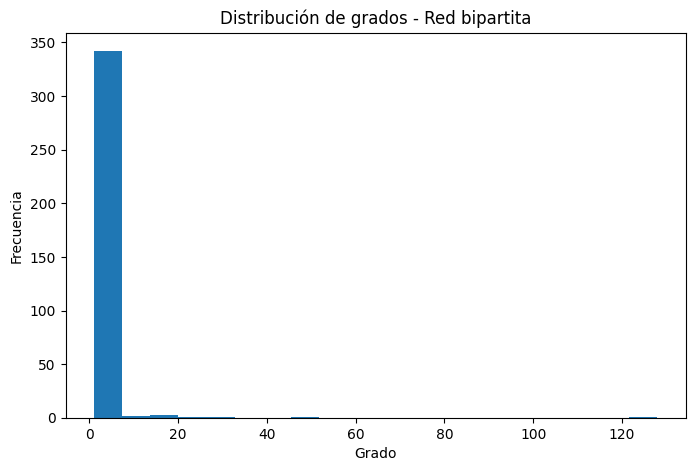

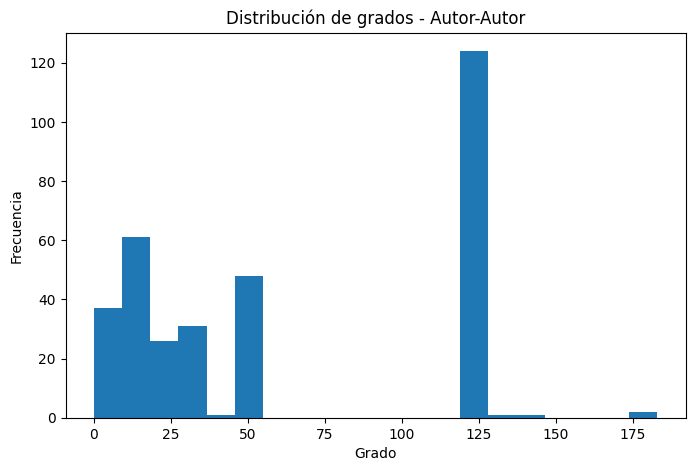

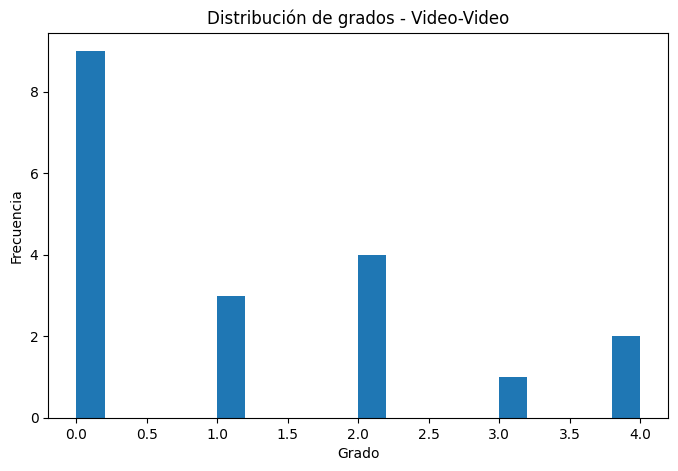

In [11]:
def graficar_grados(G, titulo):
    grados = [grado for _, grado in G.degree()]
    plt.figure(figsize=(8, 5))
    plt.hist(grados, bins=20)
    plt.xlabel("Grado")
    plt.ylabel("Frecuencia")
    plt.title(titulo)
    plt.show()

graficar_grados(G, "Distribución de grados - Red bipartita")
graficar_grados(G_autores, "Distribución de grados - Autor-Autor")
graficar_grados(G_videos, "Distribución de grados - Video-Video")

En la red Autor-Autor, sus nodos están muy conextados, mientras que en las otras, se tienen muy pocas conexiones.

#### Conexiones entre nodos.

In [12]:
def resumen_grados(G):
    grados = pd.Series(dict(G.degree()))
    return grados.describe()

print("Bipartita")
display(resumen_grados(G))
print("Autor-Autor")
display(resumen_grados(G_autores))
print("Video-Video")
display(resumen_grados(G_videos))

Bipartita


count    351.000000
mean       1.954416
std        7.716267
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      128.000000
dtype: float64

Autor-Autor


count    332.000000
mean      64.650602
std       51.832564
min        0.000000
25%       18.000000
50%       48.000000
75%      127.000000
max      183.000000
dtype: float64

Video-Video


count    19.000000
mean      1.157895
std       1.384965
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       4.000000
dtype: float64

Solo la red Autor-Autor tiene una alta cantidad de conexiones, teniendo hasta 18 conexiones en su primer cuartil.  
La red Video-Video, un poco menos de la mitad de sus nodos tiene al menos 2 conexiones.  
La red Bipartita, la gran mayoría de sus nodos solo tienen una conexión, pero hay nodos muy conectados (estos deberían ser videos).

### 6.2) Cohesión y transitividad.

In [13]:
def cohesion_transitividad(G, nombre):
    mayor = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    return {
        "red": nombre,
        "cohesion": nx.node_connectivity(mayor) if mayor.number_of_nodes() > 1 else 0,
        "transitividad": nx.transitivity(G)
    }

cohesion = pd.DataFrame([
    cohesion_transitividad(G, "Bipartita"),
    cohesion_transitividad(G_autores, "Autor-Autor"),
    cohesion_transitividad(G_videos, "Video-Video")
])

cohesion

,red,cohesion,transitividad
0,Bipartita,1,0.000000
1,Autor-Autor,1,0.984025
2,Video-Video,1,0.315789


Cohesión:  Qué tan fuertemente conectado está un grafo y qué tan difícil es fragmentarlo al eliminar componentes.  
Transitividad: Probabilidad de que dos nodos que comparten un vecino común también estén conectados entre sí.  
  
Todas las redes están a una conexión de perder una componente, esto se debe a que tienen componentes periféricos (se muestra en el siguiente inciso).  
La transitividad es mucho mayor en la red Autor-Autor, esto debido a su gran cantidad de conexiones, hace que la mayoría de nodos estén conectados entre sí. En la red Bipartita es 0, ya que es un requisito para ser bipartita. En la de video-video, solo cerca de 1/3 cumple con el criterio de transitividad.

### 6.3) Grupos periféricos y aislados.

In [14]:
def perifericos_aislados(G, nombre):
    aislados = list(nx.isolates(G))
    perifericos = [nodo for nodo, grado in G.degree() if grado == 1]
    print(nombre)
    print("Aislados:", len(aislados))
    print("Periféricos:", len(perifericos))
    return aislados, perifericos

aislados_bip, perifericos_bip = perifericos_aislados(G, "Bipartita")
print('--------------------')
aislados_autores, perifericos_autores = perifericos_aislados(G_autores, "Autor-Autor")
print('--------------------')
aislados_videos, perifericos_videos = perifericos_aislados(G_videos, "Video-Video")

Bipartita
Aislados: 0
Periféricos: 327
--------------------
Autor-Autor
Aislados: 4
Periféricos: 2
--------------------
Video-Video
Aislados: 9
Periféricos: 3


Aislados: No tienen conexiones.  
Periféricos: Solo tienen una conexión.  
  
En la red bipartita no pueden existir nodos aislados, la mayoría de sus nodos, en este caso son periféricos (327 de 351).

In [15]:
print("Autores aislados:", aislados_autores[:10])
print("Autores periféricos:", perifericos_autores[:10])
print("Videos aislados:", aislados_videos[:10])
print("Videos periféricos:", perifericos_videos[:10])

Autores aislados: ['autor::UCPLW0HE3siElqCgXfgWxMqg', 'autor::UCQM2tCKRRytVDRxNUfCDqQQ', 'autor::UC_NRVt2UP88ZNTwzrZ66JSg', 'autor::UC6xI_MOaxajIWpoP8BH6E_Q']
Autores periféricos: ['autor::UCJxJC56BSAX-ArD0NAb9qnQ', 'autor::UCyor0Mmm0ivLX2jIdyGp84Q']
Videos aislados: ['video::3Nfp9h5avBI', 'video::JkpVO1hx2f8', 'video::OkXlHx0hx-8', 'video::TT4qJ5FXHYE', 'video::UhL9y3KUl8E', 'video::X_FAIef8qlE', 'video::lj983NWyAQY', 'video::s0eco-BofOs', 'video::zweosulrwA8']
Videos periféricos: ['video::06mFNPU0aB8', 'video::b_Hkrkl3adA', 'video::is3Mk5oC19g']


Se muestran algunos id's de videos y autores que están aisaldos o son periféricos.  
El hecho de aparecer como aislados o periféricos no quiere decir que sea la realidad del autor o el video, solo que en el datos analizados, solo se cuentan con las conexiones que los hacen ser aislados o periféricos.

### 6.4) Hallazgos estructurales.

In [16]:
for nombre, red in [("Bipartita", G), ("Autor-Autor", G_autores), ("Video-Video", G_videos)]:
    grados = pd.Series(dict(red.degree()))
    print(nombre)
    print("Mediana:", grados.median())
    print("Máximo:", grados.max())
    print("Nodos grado 1:", (grados == 1).sum())
    print("Nodos grado 0:", (grados == 0).sum())
    print('----------------------------------')

Bipartita
Mediana: 1.0
Máximo: 128
Nodos grado 1: 327
Nodos grado 0: 0
----------------------------------
Autor-Autor
Mediana: 48.0
Máximo: 183
Nodos grado 1: 2
Nodos grado 0: 4
----------------------------------
Video-Video
Mediana: 1.0
Máximo: 4
Nodos grado 1: 3
Nodos grado 0: 9
----------------------------------


Los autores están conectados más con otros autores que los videos con otros videos, esto puede verse desde la red bipartira donde los nodos de los autores son muchos más que los nodos de videos. Además se observan que existen datos aisaldos, lo cual podría interpretarse como videos de nicho.

## Inciso 7.

### Selección de una red.

In [17]:
red_comunidades = G_videos.copy()

Se seleccionó la red de videos, debido a que puede permitir entender los tipos de contenidos que más comparte una audiencia.

### 7.2) Detección de comunidades con Louvain.

In [20]:
comunidades = louvain_communities(red_comunidades, weight="weight", resolution=1.0, threshold=1e-7, seed=0)
comunidades = sorted(comunidades, key=len, reverse=True)
comunidad_nodo = {nodo: i + 1 for i, comunidad in enumerate(comunidades) for nodo in comunidad}
nx.set_node_attributes(red_comunidades, comunidad_nodo, "comunidad")

Louvain busca grupos con más conexiones internas de las esperadas según la estructura general de la red.

weight="weight": Considera el número de autores compartidos.  
resolution=1.0: Resolución estándar, al aumentar este valor se generan comunidades más pequeñas.  
threshold=1e-7: Mejora mínima de modularidad para continuar optimizando.

### 7.3) Número, tamaño y modularidad.

In [25]:
resumen_comunidades = pd.DataFrame({"comunidad": range(1, len(comunidades) + 1),
                                    "numero_videos": [len(comunidad) for comunidad in comunidades]})

modularidad = modularity(red_comunidades, comunidades, weight="weight", resolution=1.0)

print("Número de comunidades:", len(comunidades))
print("Modularidad:", round(modularidad, 4))
display(resumen_comunidades)

Número de comunidades: 12
Modularidad: 0.4053


,comunidad,numero_videos
0,1,4
1,2,3
2,3,3
3,4,1
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1
9,10,1


Podemos observar en total 12 comunidades, aunque solo 3 son de interes ya que forman grupos de al menos 3 videos.  
Al tener modularidad de 0.4 podemos considerar que las conexiones no son meramente producto del azar.

### 7.4) Visualización de 3 comunidades principales.

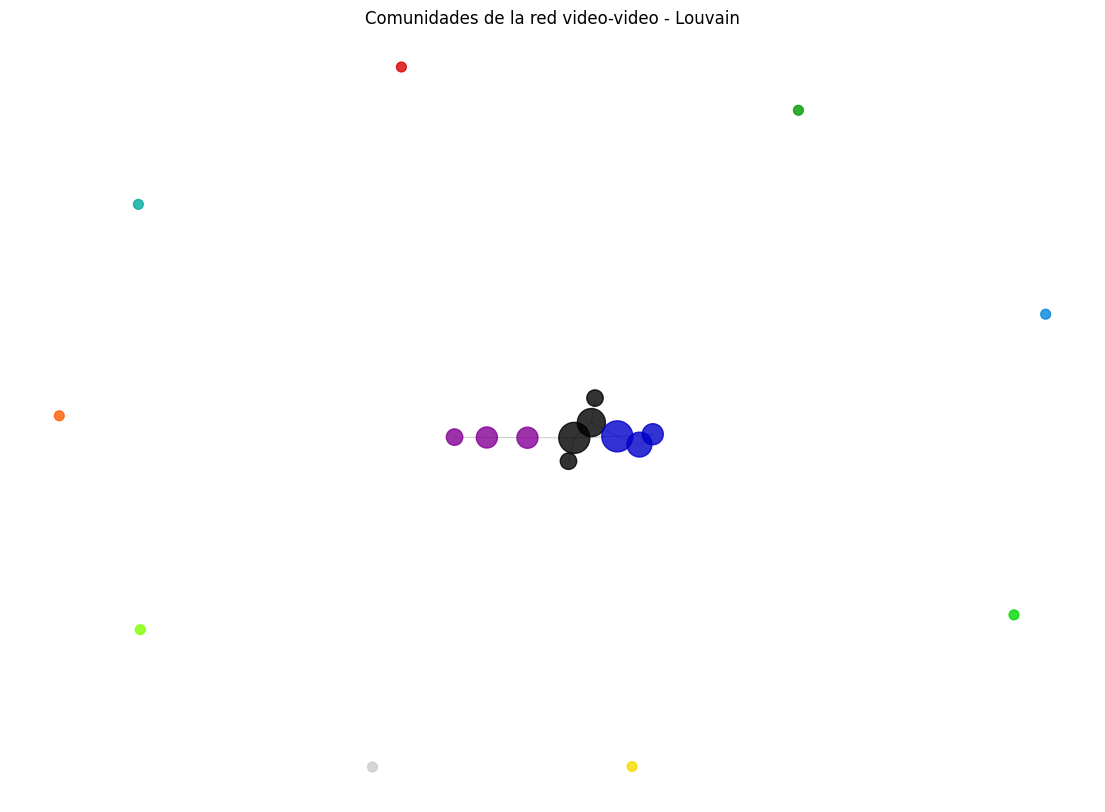

In [26]:
pos = nx.spring_layout(red_comunidades, weight="weight", seed=42, iterations=100)
fuerza = dict(red_comunidades.degree(weight="weight"))
max_fuerza = max(fuerza.values()) if fuerza else 1
tamanos = [50 + 450 * fuerza[nodo] / max_fuerza for nodo in red_comunidades.nodes()]
colores = [comunidad_nodo[nodo] for nodo in red_comunidades.nodes()]

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(red_comunidades, pos, node_size=tamanos, node_color=colores, cmap=plt.cm.nipy_spectral, alpha=0.8)
nx.draw_networkx_edges(red_comunidades, pos, width=0.6, alpha=0.25)
plt.title("Comunidades de la red video-video - Louvain")
plt.axis("off")
plt.show()

In [29]:
videos = pd.read_csv('youtube_videos.csv')
info_videos = videos.drop_duplicates("video_id").set_index("video_id")
principales = []

for i, comunidad in enumerate(comunidades[:3], 1):
    subgrafo = red_comunidades.subgraph(comunidad)
    top = sorted(subgrafo.degree(weight="weight"), key=lambda x: x[1], reverse=True)[:5]
    for nodo, grado in top:
        video_id = nodo.replace("video::", "", 1)
        principales.append({
            "comunidad": i,
            "video_id": video_id,
            "titulo": info_videos.loc[video_id, "title"],
            "canal": info_videos.loc[video_id, "channel_name"],
            "grado_ponderado": grado
        })

principales = pd.DataFrame(principales)
principales[['comunidad', 'titulo', 'canal', 'grado_ponderado']]

,comunidad,titulo,canal,grado_ponderado
0,1,La cooptación de Walter Mazariegos en la USAC,Quorum,3
1,1,Qué rico come tu diputado,Quorum,3
2,1,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,1
3,1,Capturan a ladrón que había quedado grabado mi...,TN23 Guatemala,1
4,2,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,2
5,2,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,1
6,2,Capturan a presuntos delincuentes disfrazados ...,Noti7,1
7,3,Internet: escoger el menos malo,Quorum,3
8,3,Arroz con pollo a la MONOPOLIO,Quorum,3
9,3,Caminar en una ciudad hecha para carros,Quorum,2


La primera comunidad parece tratarse de videos quetienen que ver con robos y precios altos.  
La segunda comunidad parece tratese de información de información de obras del gobierno, aunque el video del índice 6 no parece coincidir con este grupo, sino con el primeo, puede deberse al algoritmo usado.  
El tercer grupo parece pertenecer a noticias más variadas, no relacionadas con los temas de las otras comunidades.

### 7.5) Caracterización de las comunidades

#### Intensidad de participación.

In [30]:
comments = pd.read_csv('youtube_comments.csv')

mapa_comunidades = {nodo.replace("video::", "", 1): comunidad for nodo, comunidad in comunidad_nodo.items()}
comments_comunidades = comments.copy()
comments_comunidades["comunidad"] = comments_comunidades["video_id"].map(mapa_comunidades)
comments_comunidades = comments_comunidades.dropna(subset=["comunidad"])
comments_comunidades["comunidad"] = comments_comunidades["comunidad"].astype(int)

In [42]:
caracterizacion = comments_comunidades.groupby("comunidad").agg(
    videos=("video_id", "nunique"),
    canales=("channel_id", "nunique"),
    autores=("author_channel_id", "nunique"),
    comentarios=("comment_id", "count")
).reset_index()

caracterizacion["comentarios_por_video"] = caracterizacion["comentarios"] / caracterizacion["videos"]
caracterizacion["comentarios_por_autor"] = caracterizacion["comentarios"] / caracterizacion["autores"]
caracterizacion[0:3]

,comunidad,videos,canales,autores,comentarios,comentarios_por_video,comentarios_por_autor
0,1,4,3,187,225,56.250000,1.203209
1,2,3,2,62,84,28.000000,1.354839
2,3,3,1,29,34,11.333333,1.172414


#### Videos, canales y autores.

In [43]:
detalle_comunidades = []

for comunidad, datos in comments_comunidades.groupby("comunidad"):
    detalle_comunidades.append({
        "comunidad": comunidad,
        "videos_principales": datos["video_title"].value_counts().head(3).index.tolist(),
        "canales_principales": datos["channel_name"].value_counts().head(3).index.tolist(),
        "autores_principales": datos["author_name"].value_counts().head(5).index.tolist()
    })

detalle_comunidades = pd.DataFrame(detalle_comunidades)
detalle_comunidades[0:3]

,comunidad,videos_principales,canales_principales,autores_principales
0,1,"[Qué rico come tu diputado, La cooptación de W...","[Quorum, PrensaLibreOficial, TN23 Guatemala]","[@ManuelEdran, @ErvinLeonardoCarreraLatín, @by..."
1,2,[Inician los trabajos de recuperación del Puen...,"[Gobierno de la República de Guatemala, Noti7]","[@Murmullodelbarrio, @albertoshernandez5251, @..."
2,3,"[Arroz con pollo a la MONOPOLIO, Internet: esc...",[Quorum],"[@hashojea7348, @rwdm76, @Alejandro00710, @dan..."


#### Temas frecuentes.

Código del inciso 2.

In [45]:
videos_limpios = videos.copy()
comentarios_limpios = comments.copy()

def normalizar_id(serie):
    return serie.astype("string").str.strip()

def normalizar_etiqueta(valor):
    if pd.isna(valor):
        return pd.NA
    valor = unicodedata.normalize("NFKC", str(valor))
    return re.sub(r"\s+", " ", valor).strip()

ids_video = ["video_id", "channel_id"]
ids_comentario = ["video_id", "comment_id", "channel_id", "author_channel_id"]
etiquetas_video = ["channel_name", "channel_handle", "owner_handle"]
etiquetas_comentario = ["channel_name", "author_name", "author_handle"]

cambios_normalizacion = []
for col in ids_video:
    nueva = normalizar_id(videos_limpios[col])
    cambios_normalizacion.append(("videos", col, int(videos_limpios[col].astype("string").ne(nueva).sum())))
    videos_limpios[col] = nueva
for col in ids_comentario:
    nueva = normalizar_id(comentarios_limpios[col])
    cambios_normalizacion.append(("comentarios", col, int(comentarios_limpios[col].astype("string").ne(nueva).sum())))
    comentarios_limpios[col] = nueva
for col in etiquetas_video:
    nueva = videos_limpios[col].map(normalizar_etiqueta).astype("string")
    cambios_normalizacion.append(("videos", col, int(videos_limpios[col].astype("string").ne(nueva).sum())))
    videos_limpios[col] = nueva
for col in etiquetas_comentario:
    nueva = comentarios_limpios[col].map(normalizar_etiqueta).astype("string")
    cambios_normalizacion.append(("comentarios", col, int(comentarios_limpios[col].astype("string").ne(nueva).sum())))
    comentarios_limpios[col] = nueva

display(pd.DataFrame(cambios_normalizacion, columns=["archivo", "variable", "valores modificados"]))
assert videos_limpios["video_id"].is_unique
assert comentarios_limpios["comment_id"].is_unique
assert comentarios_limpios["video_id"].isin(videos_limpios["video_id"]).all()

,archivo,variable,valores modificados
0,videos,video_id,0
1,videos,channel_id,0
2,comentarios,video_id,0
3,comentarios,comment_id,0
4,comentarios,channel_id,0
5,comentarios,author_channel_id,0
6,videos,channel_name,2
7,videos,channel_handle,0
8,videos,owner_handle,0
9,comentarios,channel_name,0


In [46]:
STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "aquel", "aquella",
    "aquellas", "aquellos", "aquí", "así", "aunque", "bajo", "bien", "cada", "casi",
    "como", "con", "contra", "cual", "cuando", "de", "del", "desde", "donde", "dos",
    "durante", "e", "el", "ella", "ellas", "ellos", "en", "entre", "era", "eran",
    "eres", "es", "esa", "esas", "ese", "eso", "esos", "esta", "estaba", "están",
    "estar", "este", "esto", "estos", "fue", "han", "hasta", "hay", "la", "las",
    "le", "les", "lo", "los", "más", "me", "mi", "mis", "mucho", "muy", "nada",
    "ni", "no", "nos", "nuestra", "nuestro", "o", "otra", "otro", "para", "pero",
    "poco", "por", "porque", "que", "qué", "quien", "se", "sea", "ser", "si", "sí",
    "sin", "sobre", "son", "su", "sus", "también", "te", "tiene", "todo", "tu", "tus",
    "un", "una", "uno", "unos", "usted", "ustedes", "ya", "y", "yo",
}

def limpiar_comentario(valor):
    if pd.isna(valor):
        return ""
    texto = unicodedata.normalize("NFKC", html.unescape(str(valor))).lower()
    texto = re.sub(r"(?:https?://|www\.)\S+", " ", texto)
    texto = re.sub(r"(?<!\w)@[\w.-]+", " ", texto)
    texto = re.sub(r"#(?=\w)", "", texto)
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    tokens = [token for token in texto.split() if token not in STOPWORDS_ES]
    return " ".join(tokens)

comentarios_limpios["texto_original"] = comentarios_limpios["text"].astype("string")
comentarios_limpios["texto_limpio"] = comentarios_limpios["texto_original"].map(limpiar_comentario).astype("string")

display(comentarios_limpios[["comment_id", "texto_original", "texto_limpio"]].head(8))

,comment_id,texto_original,texto_limpio
0,Ugw-J65a1iYL9hqhELh4AaABAg,Ese corrupto amigo de la vieja fiscal los teng...,corrupto amigo vieja fiscal tengo verbose carcel
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,"Están jóvenes porque no buscan un trabajo, tu...",jóvenes buscan trabajo tuvieron suerte policía...
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,Me dejaron con ganas de demandar la ilegalidad...,dejaron ganas demandar ilegalidad reuniones vi...
3,Ugw0xgUc2ISpBr5_T654AaABAg,Veremos a este mafioso de Mazariegos en la cár...,veremos mafioso mazariegos cárcel buen tiempo ...
4,Ugw1ZzA21njWhaqQQTh4AaABAg,eso es para que salga de USA por su propio pie...,salga usa propio pie auto deporten
5,Ugw1ZzA21njWhaqQQTh4AaABAg.Aa9Tf29tBouAaB_XZQglTL,Imagine if they had to walk back home.,imagine if they had to walk back home
6,Ugw2014OIYf336oytFt4AaABAg,buenísima investigacion :hand-purple-blue-peac...,buenísima investigacion hand purple blue peace...
7,Ugw2bSVOoNn2pc8ZcUl4AaABAg,"Lleven su lonchera, sacrifiquense un poco. Y r...",lleven lonchera sacrifiquense reintevren diner...


In [47]:
comments_comunidades = comments_comunidades.merge(comentarios_limpios[["comment_id", "texto_limpio"]],
                                                  on="comment_id", how="left")

def temas_frecuentes(datos, n=10):
    palabras = " ".join(datos["texto_limpio"].dropna().astype(str)).split()
    return [palabra for palabra, _ in Counter(palabras).most_common(n)]

temas = pd.DataFrame([{"comunidad": comunidad, "temas_frecuentes": temas_frecuentes(datos, n=10)}
                      for comunidad, datos in comments_comunidades.groupby("comunidad")])

temas[0:3]

,comunidad,temas_frecuentes
0,1,"[pueblo, dinero, diputados, trabajo, diputado,..."
1,2,"[presidente, guatemala, país, años, arevalo, b..."
2,3,"[excelente, empresas, solo, internet, ley, est..."


#### Sentimiento.
El análisis de sentimiento se hace en el inciso 9, pero en este caso solo se verá el nombre del título.

#### Conclusión del 7.5

La primera comunidad es la que tiene más comentarios por video, tienen sentimientos negativos, no tienen un solo canal y trata principalmente de temas de corrupción y robos.  
La primera comunidad es la segunda con más comentarios por video, tienen sentimientos principalmente neutro, pero uno negativo, no tienen un solo canal y trata principalmente de información política.  
El tercer grupo tiene la menor cantidad de comentarios por video, no se identificó ningún tipo de sentimiento, solo son hechos por un canal y trata de temas varios.

## Inciso 8.